# Pelican 



In [31]:
import os
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from scipy.stats import norm
from astropy.io import fits
import astropy.units as u

from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.fits.gbtfitsload import GBTOffline
from dysh.util.files import dysh_data

from dysh.util.selection import Selection
from dysh.spectra.core import mean_tsys

## Helper functions

In [22]:
#from dysh.plot.vegasplot import plot_vegas
def plot_vegas(sdf, scans, title=None, tsys=False, inverse=False, edge=50, ylim=None):
    _fig, ax = plt.subplots(4, 4, sharex="col", sharey="row", gridspec_kw={"hspace": 0, "wspace": 0})

    for r in range(4):
        for c in range(4):
            p = r * 4 + c
            ax[r, c].plot()
            # ax[r,c].set_xlabel(f"{r} {c} {p}")
            for s in scans:
                v1 = sdf.gettp(scan=s, fdnum=p, ifnum=0, plnum=0, calibrate=True, cal=False).timeaverage()
                if tsys:
                    s1 = sdf.gettp(scan=s + 1, fdnum=p, ifnum=0, plnum=0, calibrate=True, cal=False).timeaverage()
                    vs = s1.data / (v1.data - s1.data)
                    if inverse:
                        vs = 1 / vs
                else:
                    vs = v1.data
                ax[r, c].plot(vs[edge:-edge], label=f"{p}")
                if tsys:
                    # note wwe haven't put a proper channel / freq axis
                    nc = len(vs[edge:-edge])
                    fix = np.ones(nc)
                    ax[r, c].plot(fix, color="black")
                # ax[r,c].scatter([0,900],[vs[edge],vs[-edge]], label=f"{p}")

                if ylim is not None:
                    ax[r, c].set_ylim(ylim)
            ax[r, c].legend()
    if title is None:
        plt.suptitle(sdf.filenames()[0])
    else:
        plt.suptitle(title)
    plt.tight_layout()

    if tsys:
        print(f"Showing sky/(vane-sky) for scans={scans},scans+1")
    else:
        print(f"Showing total power for scans={scans}")


In [29]:
def tsys(sdf, scan):
    t=np.zeros(16)
    for f in range(16):
        t[f] = sdf.vanecal(scan=scan,fdnum=f)
    return t

/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedi

array([354.8047871 , 214.04754535, 208.12731318, 224.23240684,
       220.30377009, 477.76318209, 295.26190841, 226.19300512,
       217.7906707 , 197.85939344, 208.89637247, 228.10940189,
       212.10857026, 202.98563411, 207.47965382, 197.18402752])

## Data Loading

In [23]:
sdf=GBTOffline('AGBT25B_386_01')
sdf.summary()
pscans = [31.32.35.36.37.38,39,40,41,51,52,53,54,55,56,57,58]


SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
30,PelicanCenter,0.0,Track,1,88.9095,1,1,60,16,62.0905,45.7890
31,PelicanCenter,0.0,RALongMap,1,88.9095,1,1,277,16,62.3027,46.3188
32,PelicanCenter,0.0,RALongMap,2,88.9095,1,1,277,16,62.5872,47.1576
33,VANE,0.0,Track,1,88.9095,1,1,10,16,63.0282,48.1982
34,SKY,0.0,Track,1,88.9095,1,1,10,16,63.0287,48.1982
35,PelicanCenter,0.0,Track,1,88.9095,1,1,60,16,62.9847,48.4589
36,PelicanCenter,0.0,RALongMap,3,88.9095,1,1,277,16,63.1769,48.9946
37,PelicanCenter,0.0,RALongMap,4,88.9095,1,1,277,16,63.4310,49.8428
38,PelicanCenter,0.0,RALongMap,5,88.9095,1,1,277,16,63.6736,50.6889
39,PelicanCenter,0.0,RALongMap,6,88.9095,1,1,277,16,63.9057,51.5407


In [51]:
pscans = [31,32,36,37,38,39,40,41,51,52,53,54,55,56,57,58]
pscans = [36,37,38,39,40,41,51,52,53,54,55,56,57,58]
tscans = [30,35]

In [52]:
sbp = sdf.gettp(scan=pscans, ifnum=0, plnum=0, fdnum=1)
sbt = sdf.gettp(scan=tscans, ifnum=0, plnum=0, fdnum=1)

In [54]:
sbp.plot().write('junk1.fits', overwrite=True)

In [50]:
sbt.plot().write('junk2.fits', overwrite=True)

## Plotting the 16 ARGUS beams

Plotting total power and (normalized) Tsys for the 16 beams

/home/teuben/GBT/anaconda3/lib/python3.13/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Showing total power for scans=[33, 34]


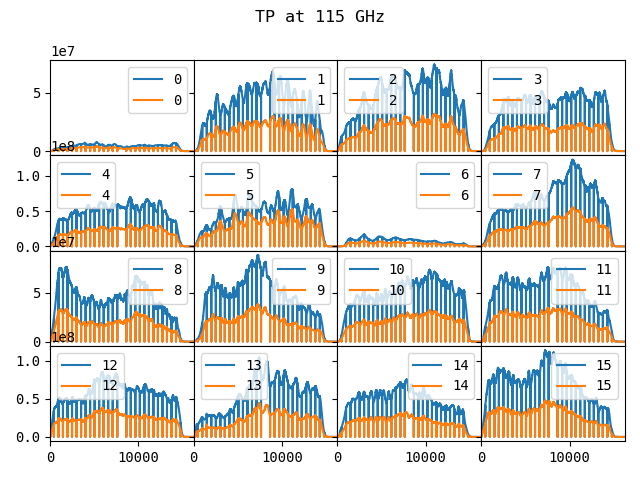

In [24]:
plot_vegas(sdf,[33,34],"TP at 115 GHz")
plt.show()

In [32]:
tsys_33 = tsys(sdf, 33)
tsys_42 = tsys(sdf, 42)
tsys_49 = tsys(sdf, 49)
tsys_59 = tsys(sdf, 59)

/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedian((vane.data - sky.data) / sky.data)
/home/teuben/GBT/dysh/src/dysh/fits/gbtfitsload.py:4736: RuntimeWarning: invalid value encountered in divide
  tsys = tcal / np.nanmedi

In [35]:
print(tsys_33)
print(tsys_42)
print(tsys_49)
print(tsys_59)


[354.8047871  214.04754535 208.12731318 224.23240684 220.30377009
 477.76318209 295.26190841 226.19300512 217.7906707  197.85939344
 208.89637247 228.10940189 212.10857026 202.98563411 207.47965382
 197.18402752]
[403.33851607 257.33716695 248.18383846 267.49574099 266.52527652
 579.62779387 345.31805584 270.65698248 253.41264245 237.87837736
 250.63326518 274.83259535 254.39524901 242.02474307 248.17206307
 237.47808204]
[306.31427551 174.42696837 171.5939514  185.62737697 178.77732789
 399.01162814 250.8863422  186.09757398 181.17546992 163.35908661
 173.62788242 189.0737016  176.81495846 166.77241153 171.77633714
 163.37014854]
[320.73031881 185.02920695 181.153025   194.52667493 190.62930991
 419.75520191 261.02634894 196.28637238 190.59688515 171.4882579
 180.99620347 197.97947789 185.1729533  175.88835518 181.18525211
 170.61543644]


/home/teuben/GBT/anaconda3/lib/python3.13/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Showing total power for scans=[59, 60]


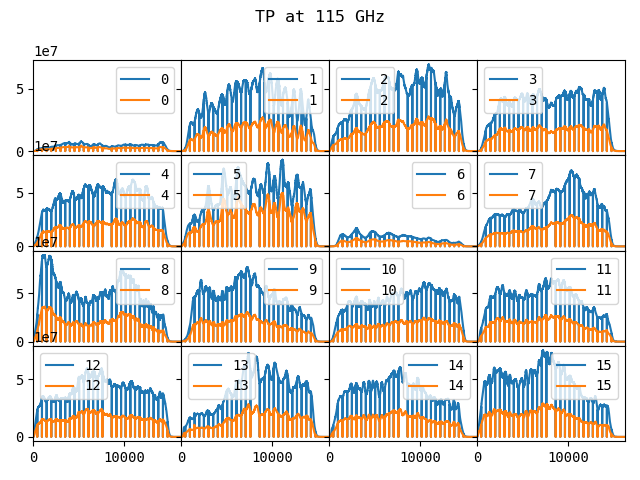

In [14]:
plot_vegas(sdf,[59,60],"TP at 115 GHz")
plt.show()

/home/teuben/GBT/anaconda3/lib/python3.13/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(
/home/teuben/GBT/dysh/src/dysh/plot/vegasplot.py:44: RuntimeWarning: invalid value encountered in divide
  vs = s1.data / (v1.data - s1.data)
/home/teuben/GBT/dysh/src/dysh/plot/vegasplot.py:44: RuntimeWarning: invalid value encountered in divide
  vs = s1.data / (v1.data - s1.data)
/home/teuben/GBT/dysh/src/dysh/plot/vegasplot.py:44: RuntimeWarning: invalid value encountered in divide
  vs = s1.data / (v1.data - s1.data)
/home/teuben/GBT/dysh/src/dysh/plot/vegasplot.py:44: RuntimeWarning: invalid value encountered in divide
  vs = s1.data / (v1.data - s1.data)
/home/teuben/GBT/dysh/src/dysh/plot/vegasplot.py:44: RuntimeWarning: invalid 

Showing sky/(vane-sky) for scans=[33],scans+1


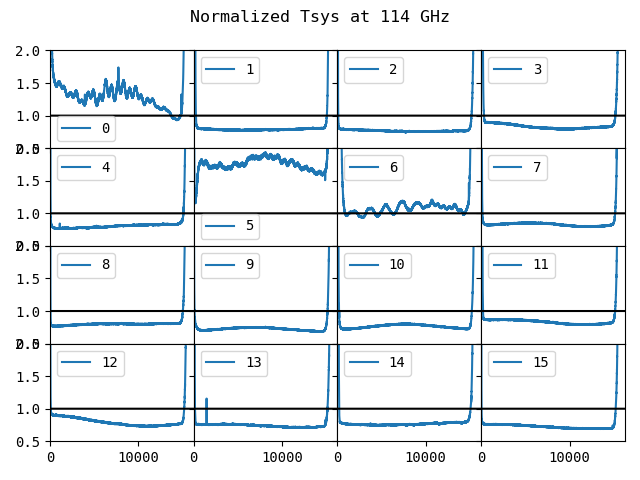

In [11]:
plot_vegas(sdf,[33],"Normalized Tsys at 116 GHz",tsys=True, ylim=[0.5,2.0])
plt.show()

In [ ]:
v1 = 

## Calibration

In [7]:
# determine the nodding beams
beam2 = sdf2.getbeam()   # 1,9
print("feeds",beam2)

# cheat here, for being offsite we can't yet get at tcal and used the previously determined Tcal 
tcal = 272    # via vanecal.pro on site


feeds [1, 9]


In [8]:
tsys2 = sdf2.vanecal([329, 330], feeds=beam2, tcal=tcal)

In [9]:
print(tsys2)  # at 114 GHz

[221.79946241 201.2739606 ]


These system temperatures look reasonable compared to what was obtained online during the observation with the VANECAL procedure in GBTIDL

Note that both `beam2` and `tsys2` are vectors of length 2

## Gather the nodding spectra

In [10]:
sp1,sp2 = sdf2._getnod([331, 332], beam2, tsys=tsys2)
sp3,sp4 = sdf2._getnod([333, 334], beam2, tsys=tsys2)
sp3 = sp1.average([sp2,sp3,sp4])
object = sp3.meta['OBJECT']

Edges of spectrum are not great, take 50 off either end

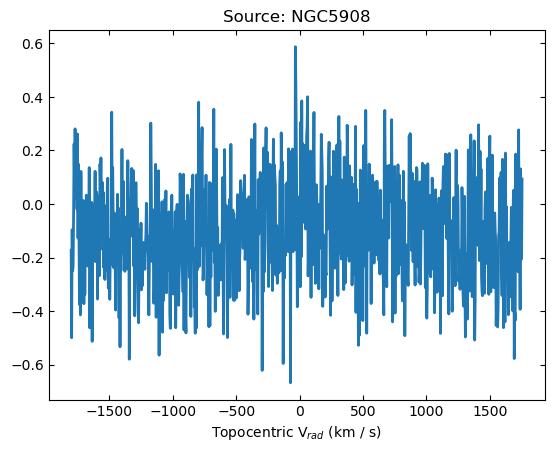

In [11]:
edge = 50
sp3[edge:-edge].plot(title=f"Source: {object}",xaxis_unit="km/s")

## Baseline subtraction and smoothing

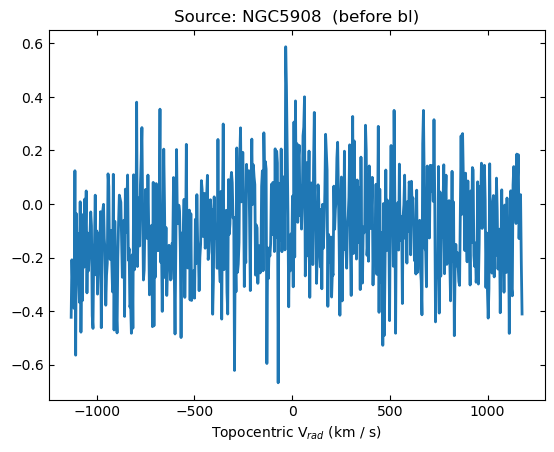

<QuantityModel Polynomial1D(9, c0=-0.01484546, c1=-0.05091137, c2=-1.05372583, c3=0.95119296, c4=3.88257231, c5=-2.78864093, c6=-5.57638837, c7=2.8376483, c8=2.62030001, c9=-0.84648245, domain=(114460430700.25, 113582989294.0)), input_units=Hz, return_units=>


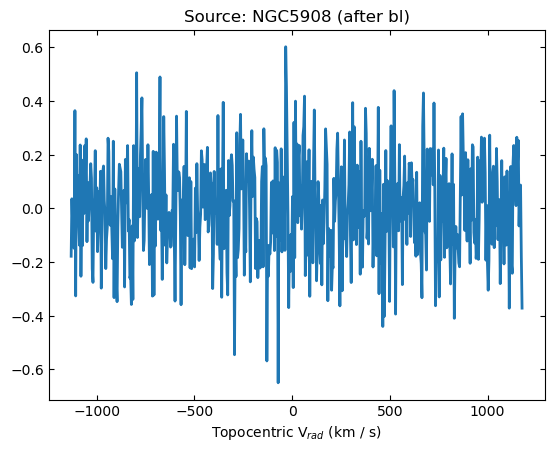

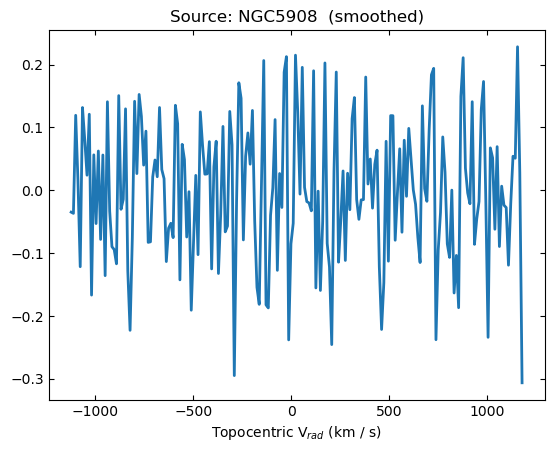

In [12]:
# do a baseline subtraction
kms = u.km/u.s
sp4=sp3[400:600]    # @todo need to figure this out in km/s   slciing should work in km/s too,but doesn't
sp4=sp3[350:650] 
sp4=sp3[300:700] 
sp4=sp3[200:800] 
#sp4=sp3
ebaselines=[-150*kms,150*kms]
ibaselines=[-150*kms,150*kms]
model="poly"
sp4.plot(title=f"Source: {object}  (before bl)",xaxis_unit="km/s")
#  include= two sections should work now [[-300,-150],[150,300]]
sp4.baseline(model=model, degree=9, exclude=ebaselines, remove=True)
#sp4.baseline(model=model, degree=5, include=ibaselines, remove=True)
# chebyshev', 'legendre', or 'hermite'
print(sp4.baseline_model)
sp4.plot(title=f"Source: {object} (after bl)",xaxis_unit="km/s")

sp5 = sp4.smooth('box', 3)
sp5.plot(title=f"Source: {object}  (smoothed)",xaxis_unit="km/s")
